In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Exporting a video and generating a template

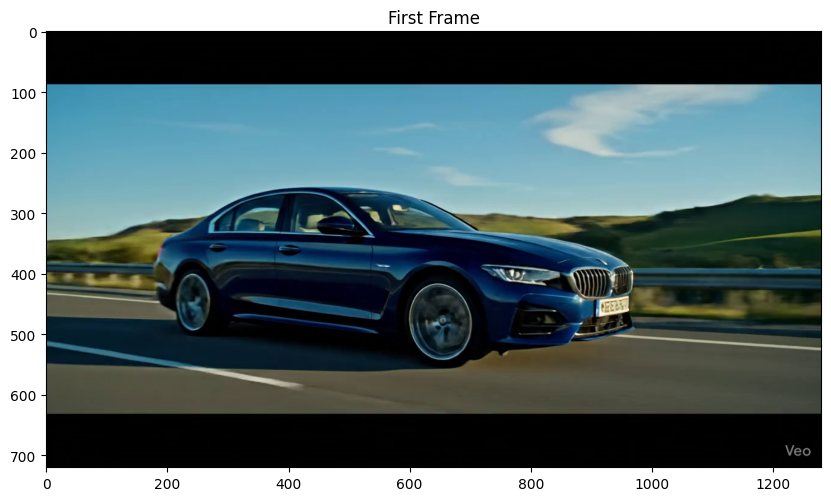

In [3]:
cap = cv2.VideoCapture("data/car_video_veo3.mp4")
ret, first_frame = cap.read()

frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.title("First Frame")
plt.imshow(frame_rgb)
plt.show()

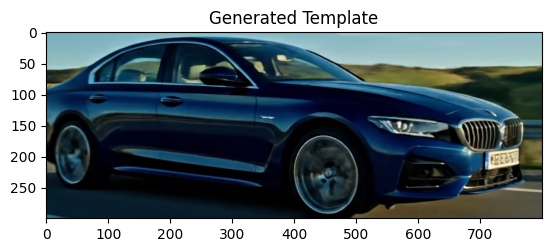

In [11]:
x, y, w, h = 200, 250, 800, 300 
template_roi = (x, y, w, h) 

template = first_frame[y:y+h, x:x+w]

cv2.imwrite("car_template.png", template)

template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)
plt.title("Generated Template")
plt.imshow(template_rgb)
plt.show()

## Initializing a KCF tracker

In [5]:
tracker_kcf = cv2.TrackerKCF_create()
tracker_kcf.init(template, roi)

## Running the tracker on the video

Let's run the tracker for 10 frames.

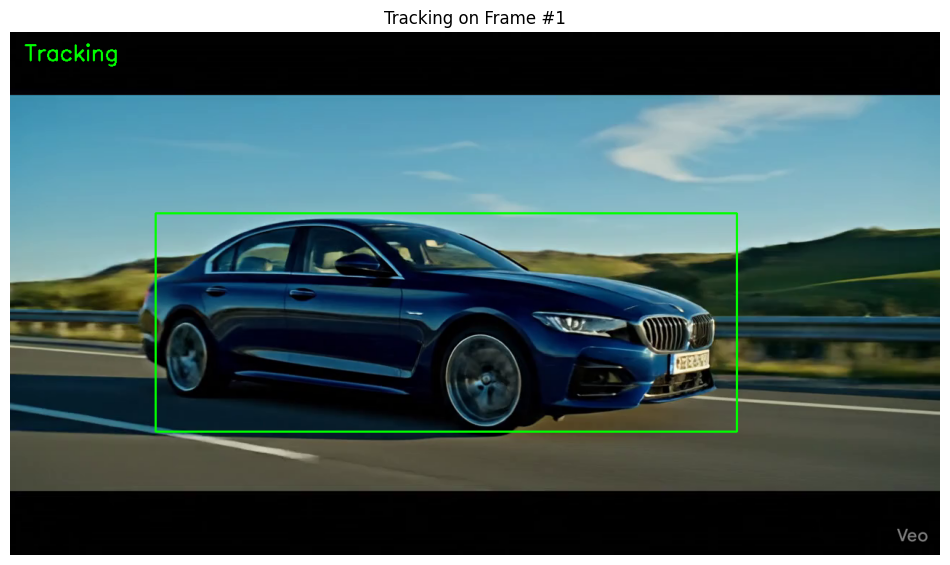

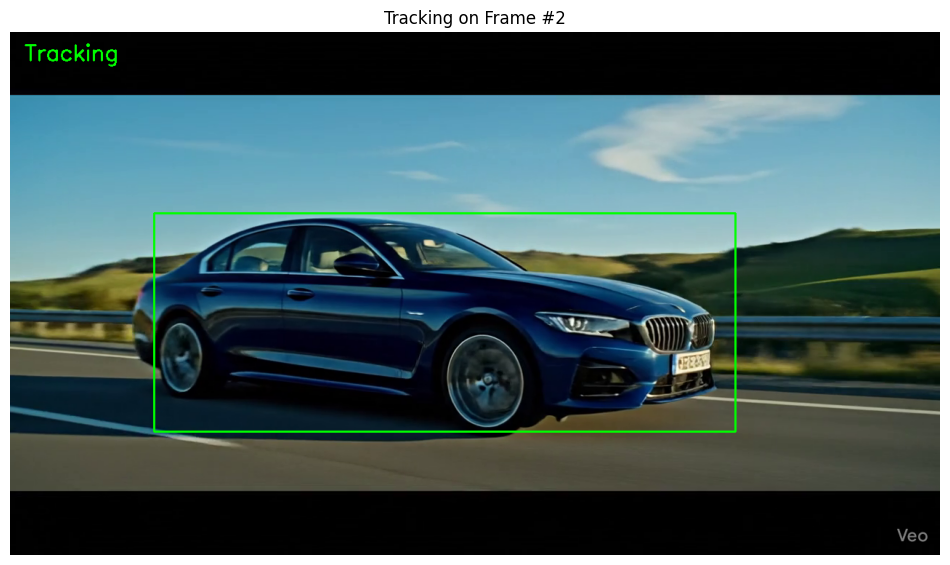

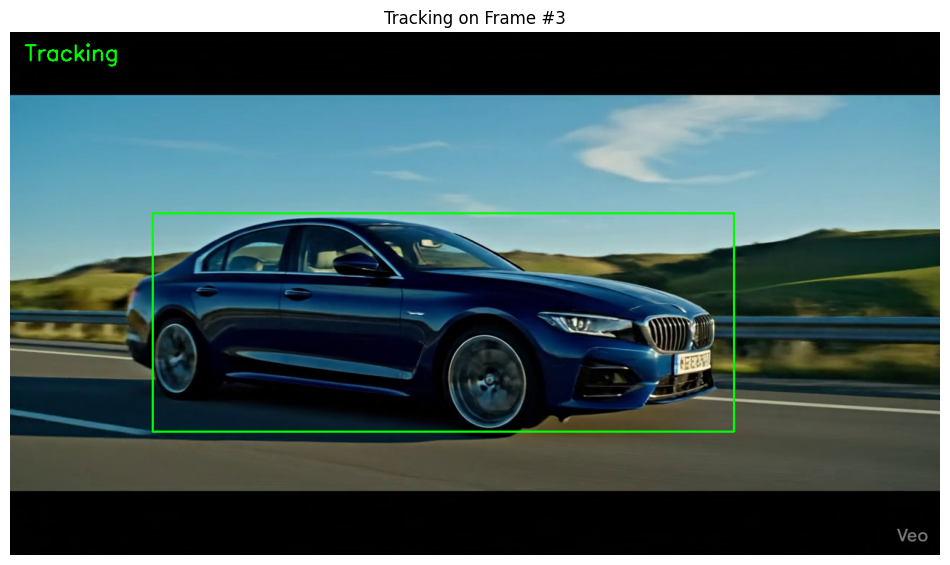

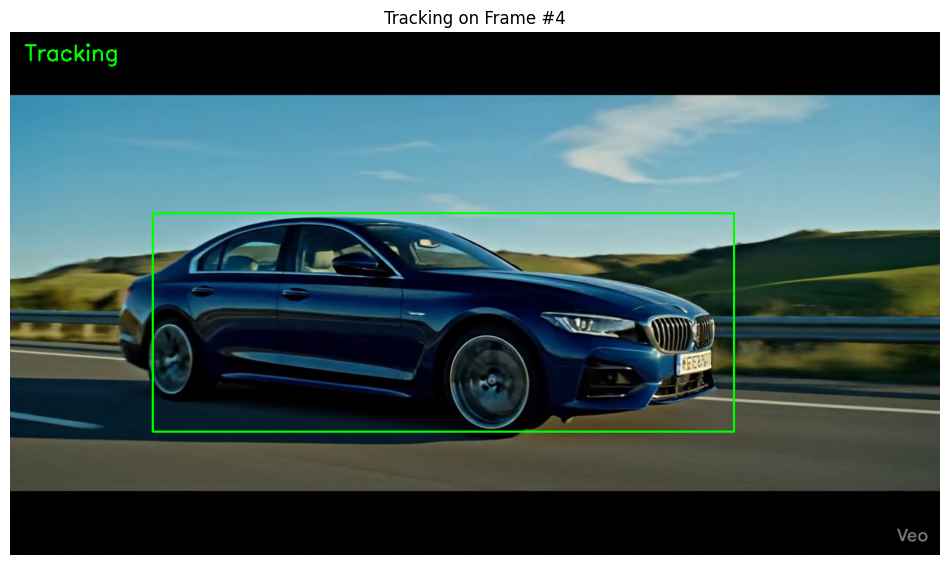

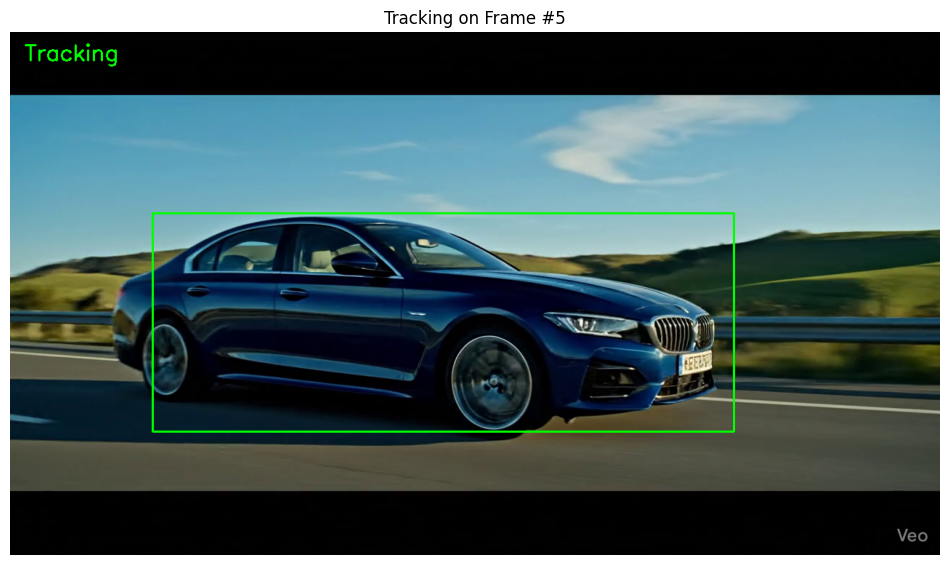

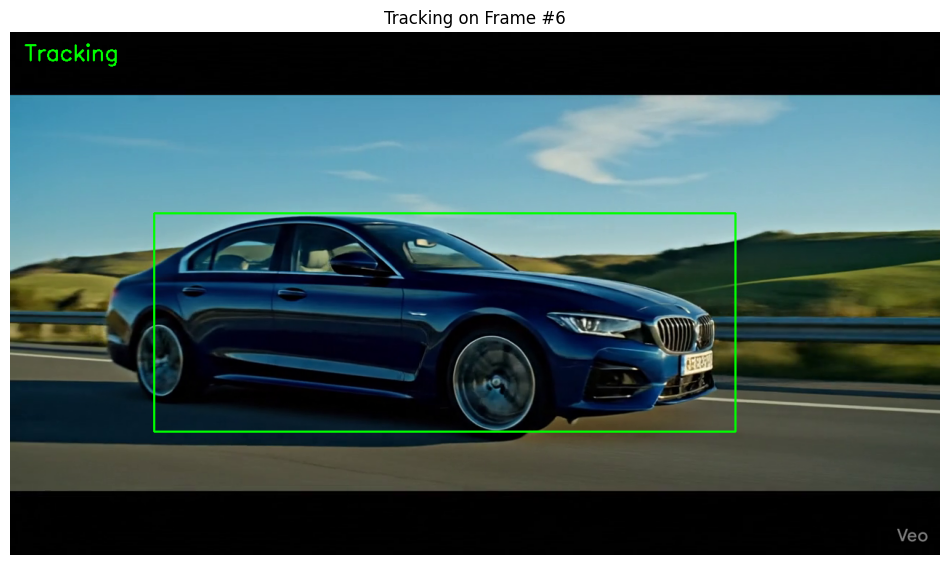

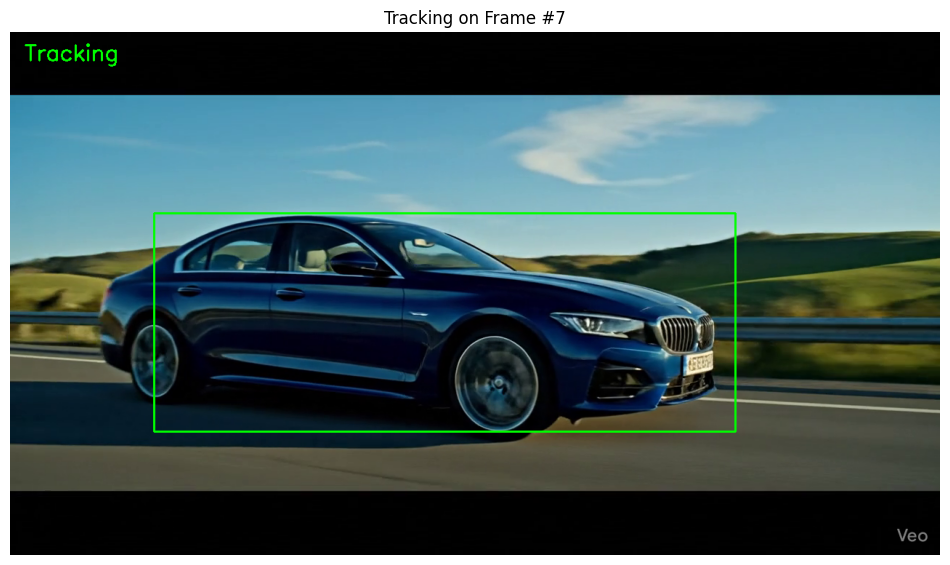

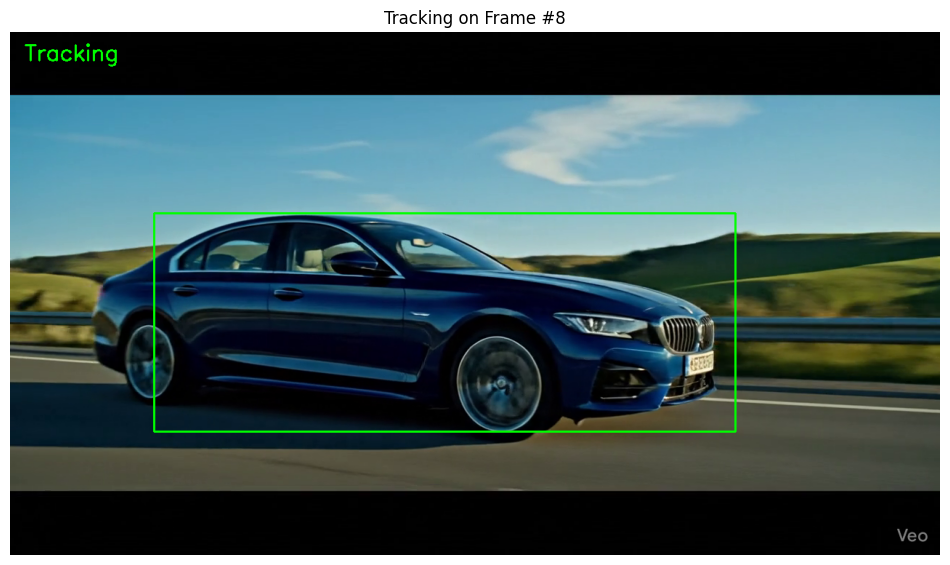

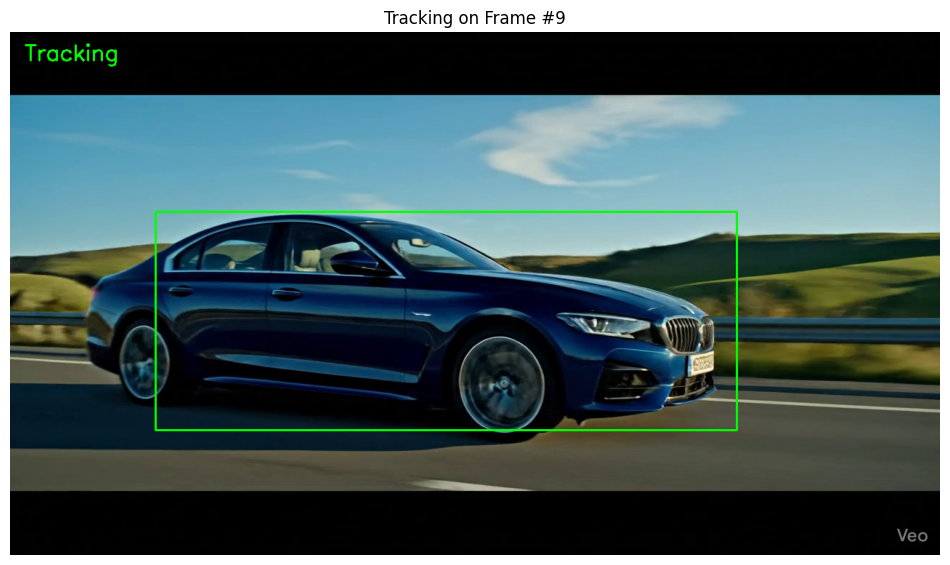

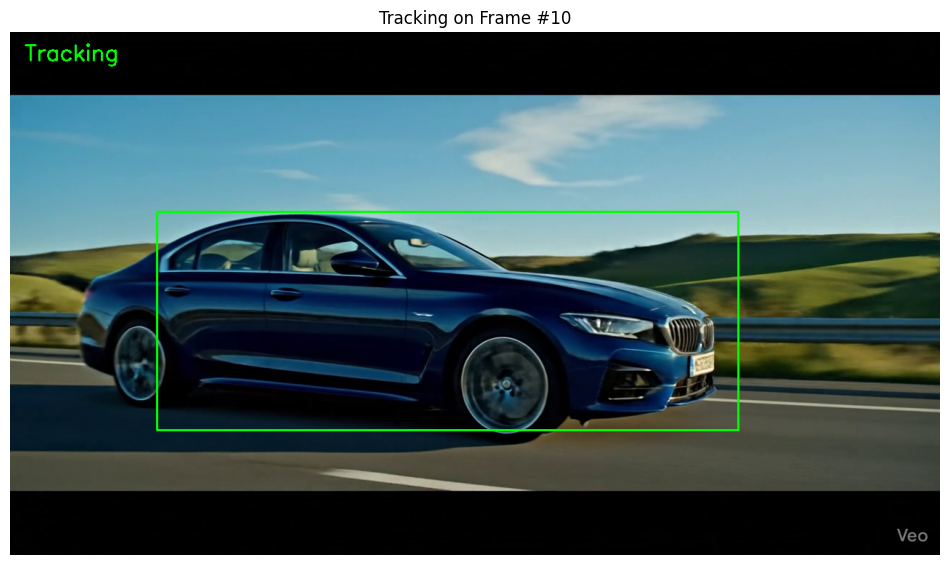

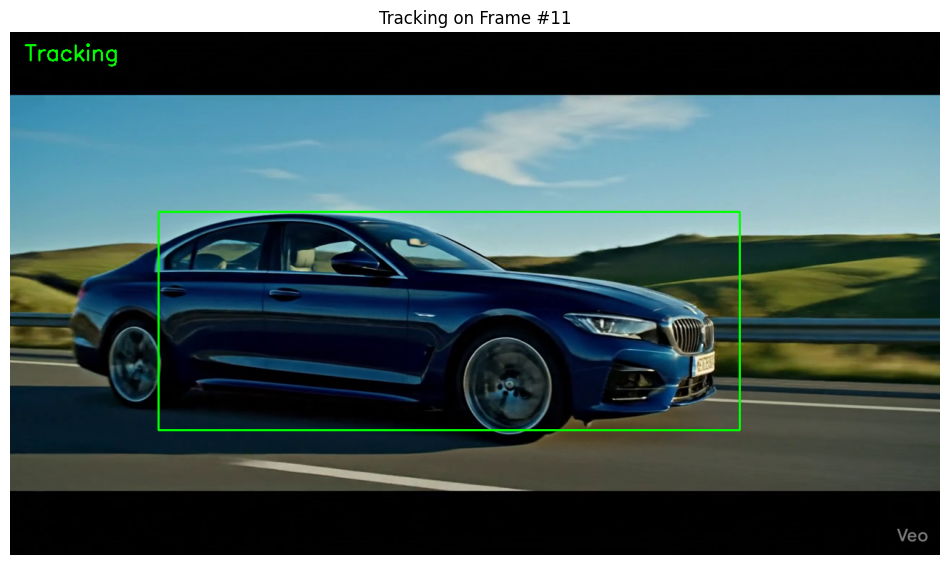

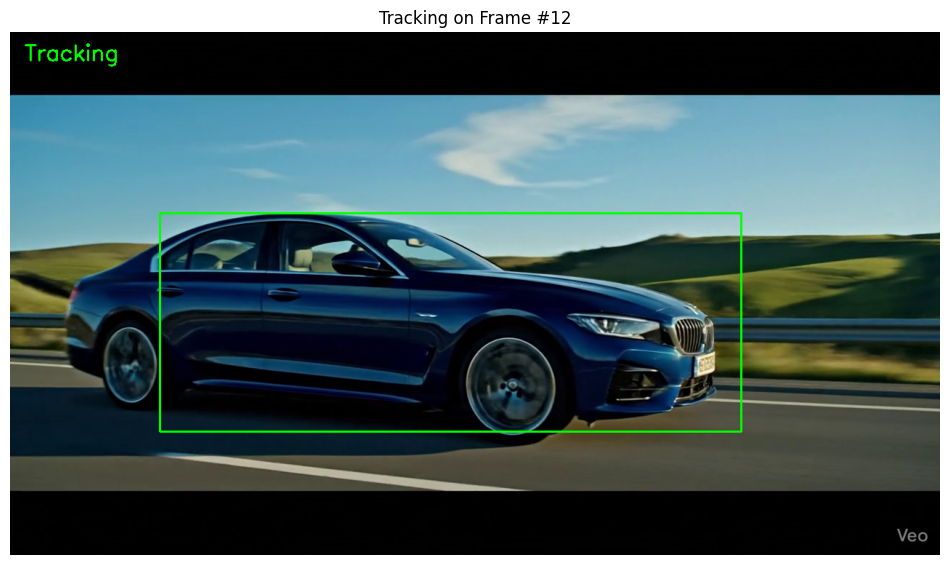

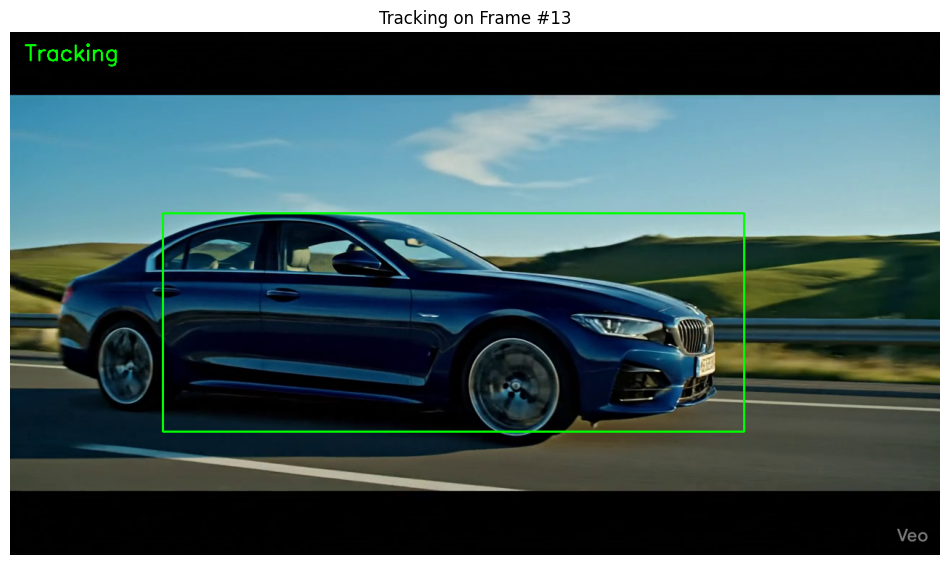

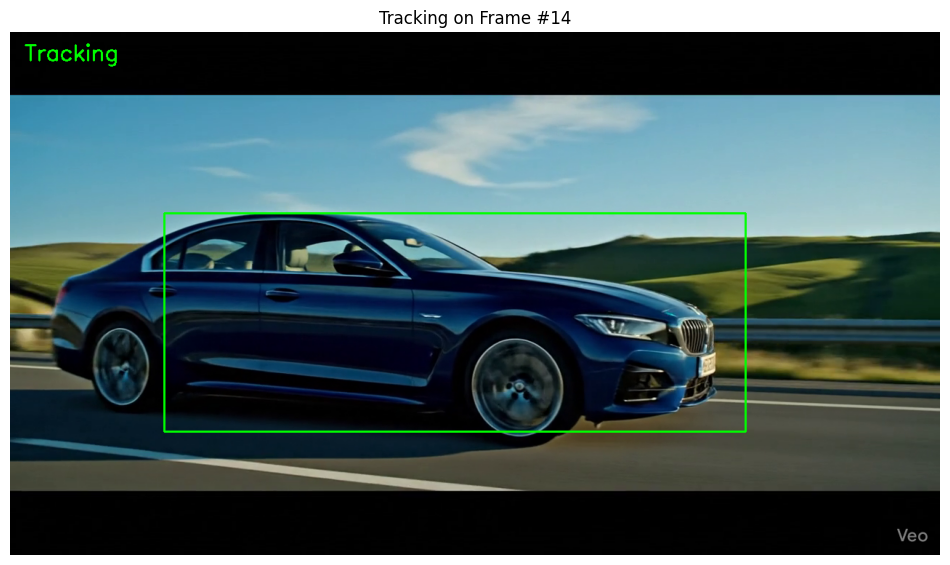

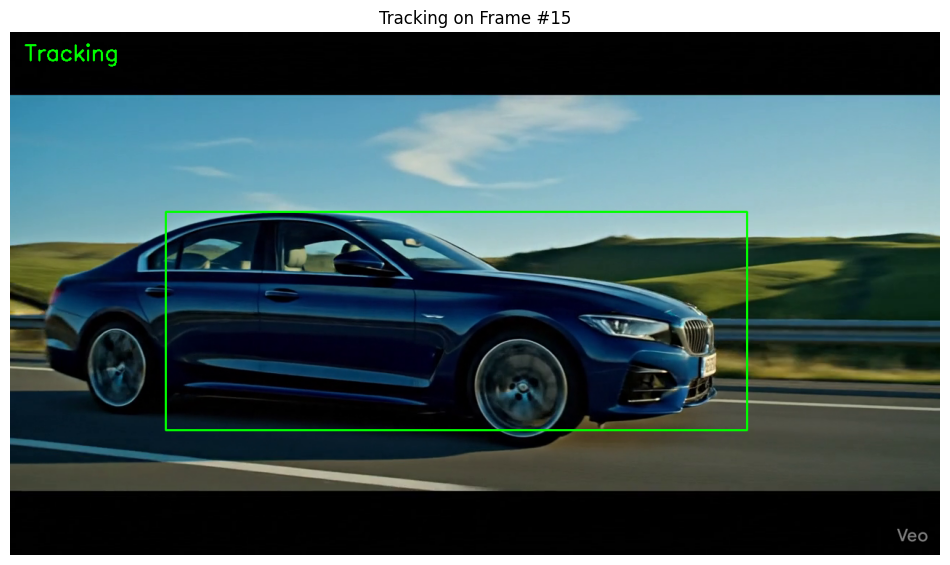

In [6]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
for i in range(15):
    ret, frame = cap.read()
    if not ret or frame is None:
        print("End of video. Exiting early.")
        break

    ok, bbox = tracker_kcf.update(frame)
    if ok:
        x, y, w, h = bbox
        p1 = (int(x), int(y))
        p2 = (int(x + w), int(y + h))
        cv2.rectangle(frame, p1, p2, (0, 255, 0), 2, 1)
        status_text = "Tracking"
        text_color = (0, 255, 0)
    else:
        status_text = "Tracking Failure"
        text_color = (0, 0, 255)

    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, text_color, 2)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8)); plt.imshow(frame_rgb)
    plt.title(f"Tracking on Frame #{i+1}")
    plt.axis('off')
    plt.show()

In [12]:
def track_on_video(cap, tracker_builder, roi, dir_name):
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    tracker = tracker_builder()
    tracker.init(first_frame, roi)
    
    frame_index = 0
    dir_path = Path(dir_name)
    dir_path.mkdir(parents=True, exist_ok=True)
    while True:
        ret, frame = cap.read()
        if not ret:
            print("End of video. Exiting.")
            break
        ok, bbox = tracker.update(frame)
        if ok:
            (x, y, w, h) = [int(v) for v in bbox]
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)
            status_text = "Tracking"
            color = (0, 255, 0)
        else:
            status_text = "Tracking Failure"
            color = (0, 0, 255)
        cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        cv2.putText(frame, f"Frame #{frame_index + 1}", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        out_path = Path(dir_name) / f"frame_{frame_index + 1:03d}.jpg"
        cv2.imwrite(out_path, frame)
        frame_index += 1
    print(f"Saved frames to {dir_path}") 


In [13]:
track_on_video(cap, cv2.TrackerKCF_create, template_roi, "kcf_frames")

End of video. Exiting.
Saved frames to kcf_frames


## Running with CSRT tracker

In [14]:
track_on_video(cap, cv2.TrackerCSRT_create, template_roi, "csrt_frames")

End of video. Exiting.
Saved frames to csrt_frames


### Do you see any differences? If so, what are they?
Yes. The CSRT tracker maintained the object throughout the video but showed minor bounding-box inaccuracies in some frames, while the KCF tracker lost the target completely around frame 88. CSRT also appeared more stable under illumination and viewpoint changes.

### Does one tracker perform better than the other? In what way?
CSRT performed better overall, as it successfully tracked the car until the end of the video, handling changes in scale, lighting, and partial occlusion. In contrast, KCF was faster but less robust, losing the object halfway through the sequence.